In [1]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
import re


In [111]:
# on Fisher Lab Guest iMAC





data_dir = Path('/Users/fisherguest/Documents/Projects/sansachen_czi')

# 2. Grab every fly*_mean_signals.csv in there
csv_files = list(data_dir.glob('fly*_mean_signals.csv'))

# 3. Read them into a dict of DataFrames,
#    keyed by 'fly#'
data = {
    f.stem.replace('_mean_signals', ''): pd.read_csv(f)
    for f in csv_files
}

# 4. (Optional) Quick sanity‑check
for name, df in data.items():
    print(name, df.shape)

# 5. Assign each DataFrame to a variable named after its key
for fly_name, df in data.items():
    globals()[fly_name] = df

fly11 (18, 5)
fly7 (18, 5)
fly3 (18, 5)
fly8 (18, 5)
fly6 (18, 5)
fly10 (18, 5)
fly9 (18, 5)
fly5 (18, 5)
fly13 (18, 5)
fly1 (18, 5)
fly12 (18, 5)
fly4 (18, 5)


In [4]:
# on sansa MACbook





data_dir = Path('/Users/sansachen/Downloads/lab/confocal/7_zipursky/mean signal value csv')

# 2. Grab every fly*_mean_signals.csv in there
csv_files = list(data_dir.glob('fly*_mean_signals.csv'))

# 3. Read them into a dict of DataFrames,
#    keyed by 'fly#'
data = {
    f.stem.replace('_mean_signals', ''): pd.read_csv(f)
    for f in csv_files
}

# 4. (Optional) Quick sanity‑check
for name, df in data.items():
    print(name, df.shape)

# 5. Assign each DataFrame to a variable named after its key
for fly_name, df in data.items():
    globals()[fly_name] = df

fly11 (18, 5)
fly7 (18, 5)
fly3 (18, 5)
fly8 (18, 5)
fly6 (18, 5)
fly10 (18, 5)
fly9 (18, 5)
fly5 (18, 5)
fly13 (18, 5)
fly1 (18, 5)
fly12 (18, 5)
fly4 (18, 5)


In [5]:
fly1

,glomerulus,mean_red,mean_green,total_red,total_green
0,glom_1,962.697885,159.971423,1.466291e+08,34883582.0
1,glom_2,946.590984,154.323150,3.136736e+08,70510562.0
2,glom_3,935.043142,156.905301,2.470303e+08,56387721.0
3,glom_4,843.692592,149.614978,2.680443e+08,63721847.0
4,glom_5,864.663045,116.448605,1.822358e+08,35904963.0
5,glom_6,850.902800,141.206419,1.709262e+08,39416768.0
6,glom_7,1274.272695,227.465083,1.204585e+09,242893358.0
7,glom_8,754.813273,94.204003,1.262476e+08,21812208.0
8,glom_9,728.383596,107.993840,8.201922e+07,15845884.0
9,glom_10,778.947420,132.570087,1.971667e+08,42273494.0


In [6]:
fly_subtype = pd.DataFrame({
    'fly': [
        'fly1','fly3','fly4','fly5','fly6',
        'fly7','fly8','fly9','fly10','fly11',
        'fly12','fly13'
    ],
    'subtype': [
        'L3R6','L7R2','L3R6','L1L9R8','L7R2',
        'L1L9R8','L6R3','L3R6','L1L9R8','L2R7',
        'L8R1R9','L7R2'
    ]
})

In [7]:
tokens = fly_subtype['subtype'].str.findall(r'[LR]\d+')

# 2. Figure out the maximum number of tokens any row has
max_parts = tokens.map(len).max()

# 3. Create column names dynamically (part1, part2, …)
col_names = [f'part{i+1}' for i in range(max_parts)]

# 4. “Unpack” the lists of tokens into separate columns
fly_subtype[col_names] = pd.DataFrame(tokens.tolist(), index=fly_subtype.index)

fly_subtype

,fly,subtype,part1,part2,part3
0,fly1,L3R6,L3,R6,None
1,fly3,L7R2,L7,R2,None
2,fly4,L3R6,L3,R6,None
3,fly5,L1L9R8,L1,L9,R8
4,fly6,L7R2,L7,R2,None
5,fly7,L1L9R8,L1,L9,R8
6,fly8,L6R3,L6,R3,None
7,fly9,L3R6,L3,R6,None
8,fly10,L1L9R8,L1,L9,R8
9,fly11,L2R7,L2,R7,None


In [8]:
subtype_to_csv_subtype = pd.DataFrame({
    'subtype': [
        'L9','L8','L7','L6','L5','L4','L3','L2','L1',
        'R1','R2','R3','R4','R5','R6','R7','R8','R9'
    ],
    'csv_subtype': [
        'glom_1','glom_2','glom_3','glom_4','glom_5','glom_6','glom_7','glom_8','glom_9',
        'glom_10','glom_11','glom_12','glom_13','glom_14','glom_15','glom_16','glom_17','glom_18'
    ]
})

# 2. Set 'subtype' as the index
subtype_to_csv_subtype = subtype_to_csv_subtype.set_index('subtype')

In [9]:
csv_to_subtype = {
    v: k
    for k, v in subtype_to_csv_subtype['csv_subtype'].items()
}

# 2. Create a new dict to hold the “_new” DataFrames
new_data = {}

for fly_name, df in data.items():
    # a) Identify the first column (currently holding glom_* values)
    first_col = df.columns[0]
    
    # b) Remap glom_* → subtype (L#/R#)
    df[first_col] = df[first_col].map(csv_to_subtype)
    
    # c) Rename that column to something meaningful
    df = df.rename(columns={ first_col: 'subtype' })
    
    # d) Store it under a new key with “_new” appended
    new_data[f'{fly_name}_new'] = df

# 3. (Optional) Inject into the global namespace so you can refer to fly1_new, fly3_new, etc.
for new_name, df in new_data.items():
    globals()[new_name] = df

In [10]:
# don't put this line in the previous cell!
fly1_new

,subtype,mean_red,mean_green,total_red,total_green
0,L9,962.697885,159.971423,1.466291e+08,34883582.0
1,L8,946.590984,154.323150,3.136736e+08,70510562.0
2,L7,935.043142,156.905301,2.470303e+08,56387721.0
3,L6,843.692592,149.614978,2.680443e+08,63721847.0
4,L5,864.663045,116.448605,1.822358e+08,35904963.0
5,L4,850.902800,141.206419,1.709262e+08,39416768.0
6,L3,1274.272695,227.465083,1.204585e+09,242893358.0
7,L2,754.813273,94.204003,1.262476e+08,21812208.0
8,L1,728.383596,107.993840,8.201922e+07,15845884.0
9,R1,778.947420,132.570087,1.971667e+08,42273494.0


In [11]:
for fly_name, df in new_data.items():
    # Split the first 9 rows into “left” and the rest into “right”
    left_df  = df.iloc[:9].reset_index(drop=True)
    right_df = df.iloc[9:].reset_index(drop=True)
    
    # Assign to new variables in the global namespace
    globals()[f"{fly_name}_left"]  = left_df
    globals()[f"{fly_name}_right"] = right_df


In [ ]:
fly13_new_right

,subtype,mean_red,mean_green,total_red,total_green
0,R1,475.453792,60.628079,80814724.0,11739260.0
1,R2,726.300695,70.154702,320131124.0,34021893.0
2,R3,512.082539,60.532340,88657633.0,11791128.0
3,R4,423.927832,48.406145,38584245.0,5270100.0
4,R5,425.249871,60.147867,65678780.0,11238003.0
5,R6,459.583969,68.160927,104501352.0,18694812.0
6,R7,515.786850,74.096065,143328562.0,25157255.0
7,R8,554.876061,88.111819,86791061.0,16638949.0
8,R9,547.776852,86.909575,63020589.0,12080245.0


In [13]:
# 1. Gather all fly*_new_left and fly*_new_right DataFrame names in globals
all_dfs = [name for name in globals() if re.match(r'fly\d+_new_(left|right)$', name)]

# 2. Exclude flies 5, 7, 10, and 12
exclude = {'fly5','fly7','fly10','fly12'}
subset_dfs = [name for name in all_dfs if name.split('_new_')[0] not in exclude]

# 3. Define ordering for left and right
left_order = [f'L{i}' for i in range(9, 0, -1)]
right_order = [f'R{i}' for i in range(1, 10)]

# 4. Loop over the subset and create shuffle_order DataFrames
for name in subset_dfs:
    df = globals()[name]
    fly = name.split('_new_')[0]       # e.g. 'fly3'
    side = name.split('_new_')[1]      # 'left' or 'right'
    codes = left_order if side == 'left' else right_order
    new_name = f"{name}_shuffle_order" # e.g. 'fly3_new_left_shuffle_order'
    
    # Build the new DataFrame
    shuffle_df = pd.DataFrame({'subtype': codes})
    
    # Determine which code to mark with 0
    part_col = 'part1' if side == 'left' else 'part2'
    target_code = fly_subtype.set_index('fly', drop=False).loc[fly, part_col]
    
    # Initialize second column and mark the target code
    shuffle_df['value'] = pd.NA
    shuffle_df.loc[shuffle_df['subtype'] == target_code, 'value'] = 0
    
    # Assign to globals
    globals()[new_name] = shuffle_df

In [14]:
fly1_new_left_shuffle_order

,subtype,value
0,L9,<NA>
1,L8,<NA>
2,L7,<NA>
3,L6,<NA>
4,L5,<NA>
5,L4,<NA>
6,L3,0
7,L2,<NA>
8,L1,<NA>


In [15]:
def fill_wrap_distances_left(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'L9' → numeric positions 9→1
      - `second_col` is NA except one row equals 0
    This will:
      1. find the row where second_col == 0,
      2. read its numeric position as the reference,
      3. compute wrap‑around distances in [-4..4],
      4. fill second_col accordingly.
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences on the numeric series
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

def fill_wrap_distances_right(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'R1' → numeric positions 1→9
      - `second_col` is NA except one row equals 0
    This will:
      1. find the reference numeric position,
      2. compute the minimal signed distance on the circular scale,
      3. fill second_col with values in [-4..4].
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

In [16]:
def fill_wrap_distances_general(df, df_name, first_col='subtype', second_col='value'):
    if 'left' in df_name:
        return fill_wrap_distances_left(df.copy(), first_col=first_col, second_col=second_col)
    elif 'right' in df_name:
        return fill_wrap_distances_right(df.copy(), first_col=first_col, second_col=second_col)
    else:
        raise ValueError(f"DataFrame name '{df_name}' must contain 'left' or 'right'.")


In [17]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# Loop through them and apply the wrapper function in one go
for name in shuffle_names:
    df = globals()[name]
    # apply the correct fill function based on “left”/“right” in the name
    filled = fill_wrap_distances_general(df, name, first_col='subtype', second_col='value')
    # overwrite the original DataFrame with the filled version
    globals()[name] = filled

In [18]:
fly6_new_right_shuffle_order

,subtype,value
0,R1,-1
1,R2,0
2,R3,1
3,R4,2
4,R5,3
5,R6,4
6,R7,-4
7,R8,-3
8,R9,-2


In [19]:
fly5_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly5_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly7_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly7_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly10_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly10_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly12_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [1,0,-1,-2,-3,-4,4,3,2]})
fly12_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})

In [20]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# 2. For each one, build a new "_for_graph" DataFrame sorted by 'value'
for name in shuffle_names:
    df       = globals()[name]
    new_name = f"{name}_for_graph"
    
    # copy & sort so you don’t mutate the original
    sorted_df = df.copy().sort_values(by='value').reset_index(drop=True)
    
    # inject it into globals under the new name
    globals()[new_name] = sorted_df

In [21]:
fly5_new_right_shuffle_order_for_graph

,subtype,value
0,R3,-4
1,R2,-3
2,R1,-2
3,R9,-1
4,R8,0
5,R7,1
6,R6,2
7,R5,3
8,R4,4


In [22]:
order_graph_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_shuffle_order_for_graph$', name)
]

# 2. Loop over each and build the corresponding *_graphing DataFrame
for order_name in order_graph_names:
    # e.g. order_name = "fly6_new_right_shuffle_order_for_graph"
    prefix     = order_name.replace('_shuffle_order_for_graph', '')  # "fly6_new_right"
    graph_name = f"{prefix}_graphing"                               # "fly6_new_right_graphing"
    
    # Get the ordered list of subtypes from the shuffle_order_for_graph
    order_list = globals()[order_name]['subtype'].tolist()
    
    # Grab the original left/right DataFrame
    df = globals()[prefix]
    
    # Reorder rows according to order_list and reset the index
    graph_df = df.set_index('subtype').loc[order_list].reset_index()
    
    # Assign the new DataFrame into the global namespace
    globals()[graph_name] = graph_df

In [52]:
fly5_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,L4,493.481073,58.269314,38549261.0,4551824.0,0.099787,-0.519552,0.303184,-0.235899,0.531537
1,L3,477.295721,44.714108,21852030.0,2047146.0,0.076573,-1.584559,0.000000,-1.699229,0.000000
2,L2,560.519954,52.841183,47543863.0,4482042.0,0.090491,-0.946030,0.181775,-0.821884,0.318685
3,L9,722.423116,89.423544,200510703.0,24819773.0,0.153139,1.928178,1.000000,NaN,NaN
4,L1,685.092040,71.333490,296820922.0,30905734.0,0.122159,0.506876,0.595386,NaN,NaN
5,L8,543.262223,70.216035,41402014.0,5351164.0,0.120246,0.419080,0.570392,1.053789,1.000000
6,L7,511.671263,69.493748,80444956.0,10925807.0,0.119009,0.362331,0.554237,0.975816,0.971677
7,L6,527.683710,62.298235,101037183.0,11928430.0,0.106686,-0.203007,0.393298,0.199036,0.689522
8,L5,490.952742,65.348951,70487558.0,9382345.0,0.111911,0.036682,0.461532,0.528371,0.809148


In [55]:
fly5_new_left_graphing.iloc[[3, 4]] = fly5_new_left_graphing.iloc[[4, 3]].values
fly7_new_left_graphing.iloc[[3, 4]] = fly7_new_left_graphing.iloc[[4, 3]].values
fly10_new_left_graphing.iloc[[3, 4]] = fly10_new_left_graphing.iloc[[4, 3]].values

fly7_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,L4,87.751278,19.350997,5388353.0,957598.0,0.135158,1.325940,1.000000,1.250001,1.000000
1,L3,95.457742,14.954691,6956252.0,762866.0,0.104452,-0.367171,0.453832,-0.268930,0.453832
2,L2,104.256448,11.301636,4166999.0,350398.0,0.078937,-1.774041,0.000000,-1.531067,0.000000
3,L1,138.238451,15.356616,49728767.0,4795966.0,0.107259,-0.212381,0.503764,NaN,NaN
4,L9,119.530189,17.684653,54761364.0,6948485.0,0.123520,0.684196,0.792984,NaN,NaN
5,L8,98.799708,12.713668,4319196.0,403259.0,0.088800,-1.230237,0.175422,-1.043208,0.175422
6,L7,76.669910,17.160239,1908521.0,376774.0,0.119857,0.482232,0.727835,0.493090,0.727835
7,L6,79.564674,17.919903,6298327.0,1023208.0,0.125163,0.774795,0.822210,0.755556,0.822210
8,L5,82.436950,16.730335,5326438.0,806332.0,0.116854,0.316667,0.674426,0.344558,0.674426


In [ ]:
names = [
    'fly5_new_left_graphing', 'fly5_new_right_graphing',
    'fly7_new_left_graphing', 'fly7_new_right_graphing',
    'fly10_new_left_graphing', 'fly10_new_right_graphing',
    'fly12_new_left_graphing', 'fly12_new_right_graphing'
]

for name in set(names):  # set(...) just dedups any repeats
    # grab the df from the global namespace
    df = globals()[name]
    
    # reverse the rows and reset the index if you want 1…9 again
    df_rev = df.iloc[::-1].reset_index(drop=True)
    
    # put it back in globals under the same name
    globals()[name] = df_rev

fly5_new_left_graphing

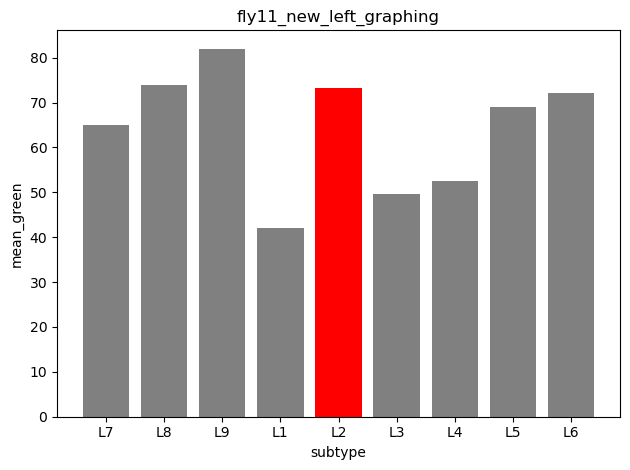

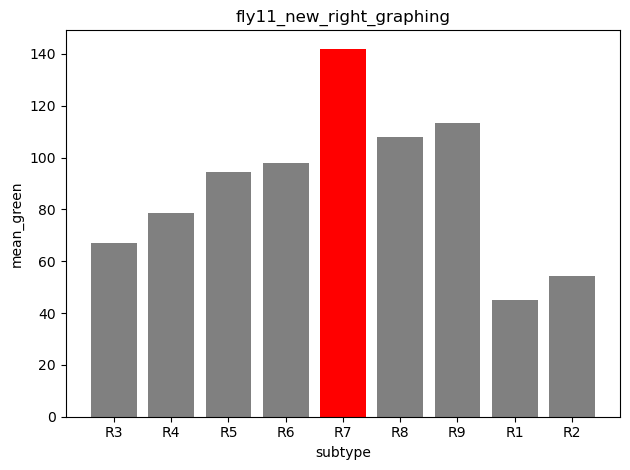

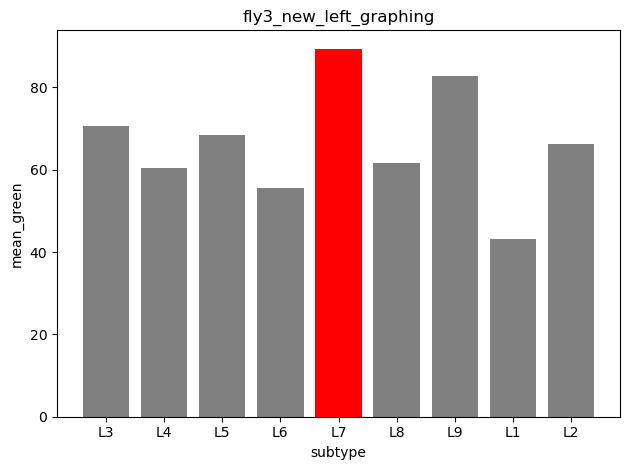

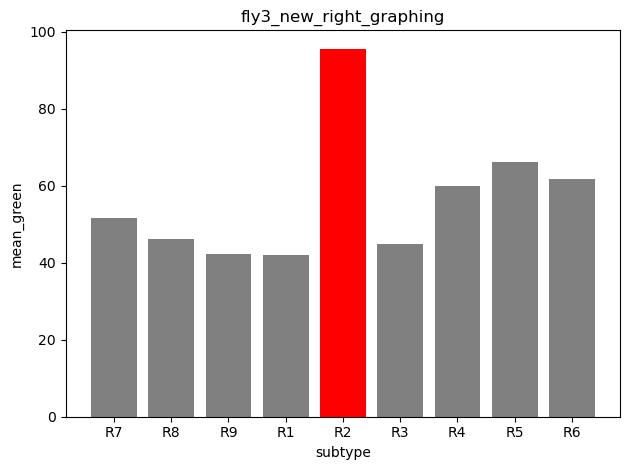

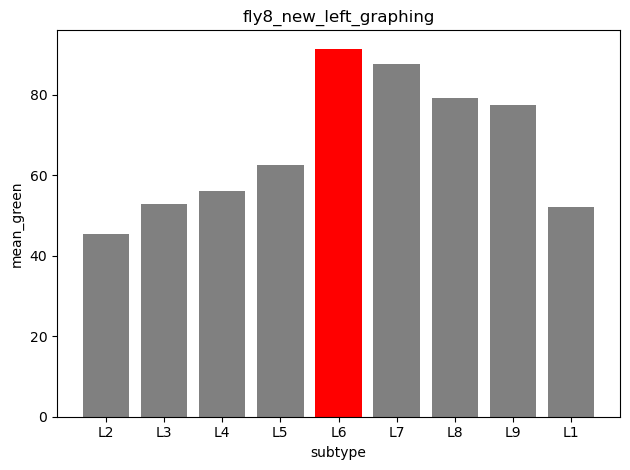

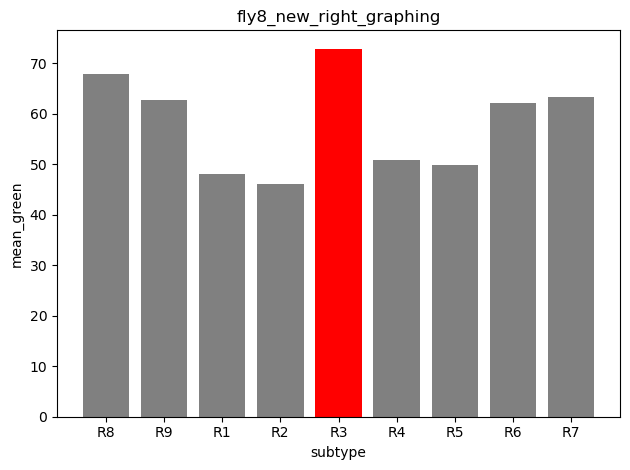

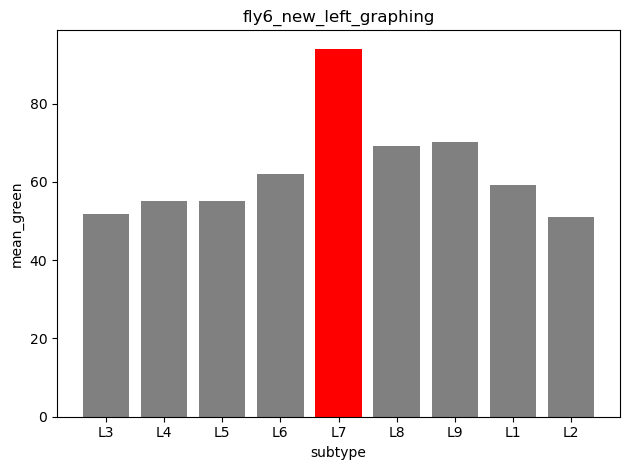

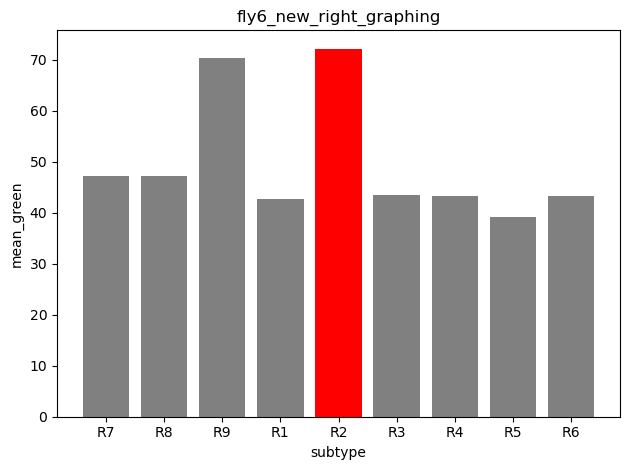

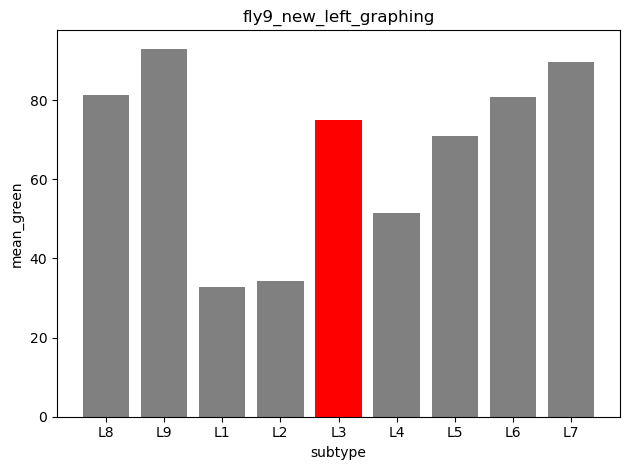

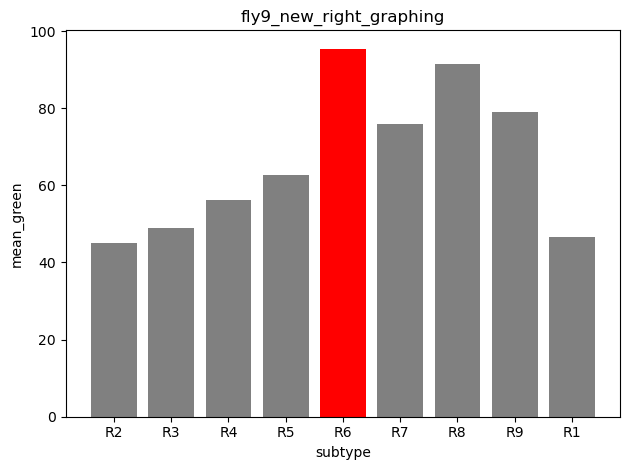

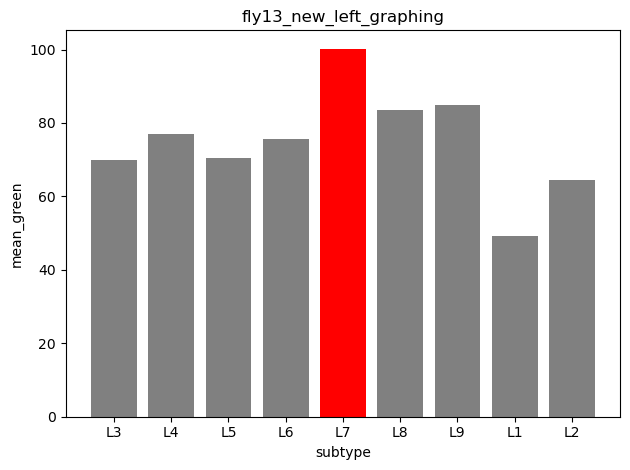

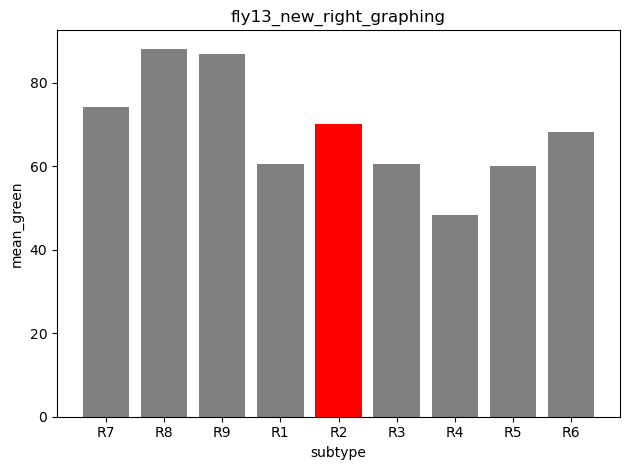

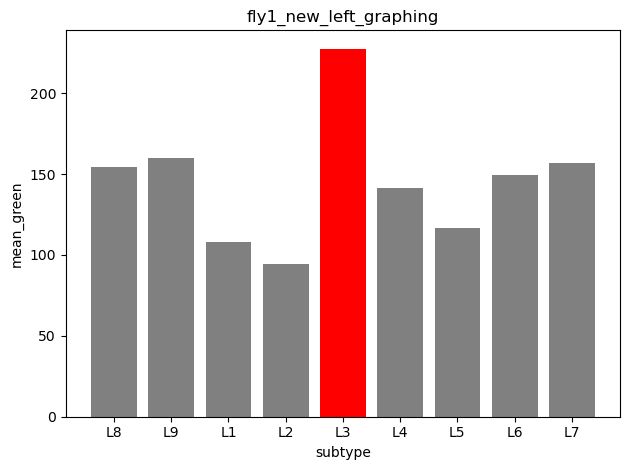

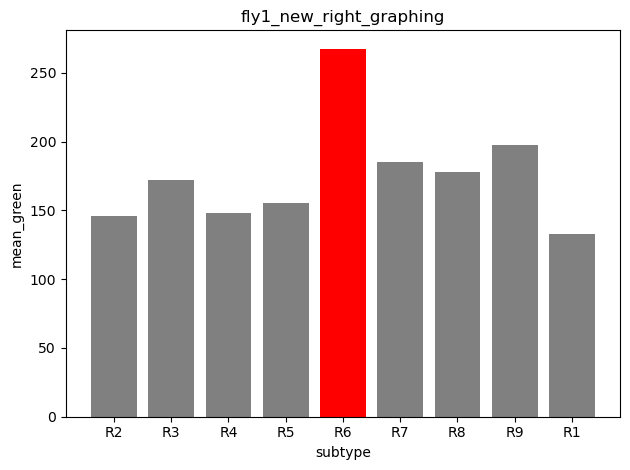

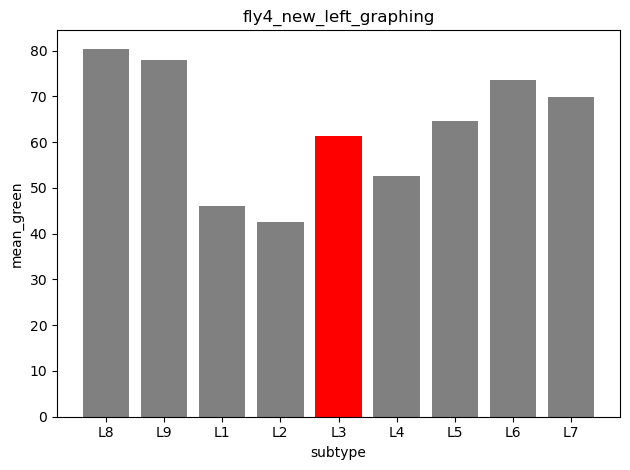

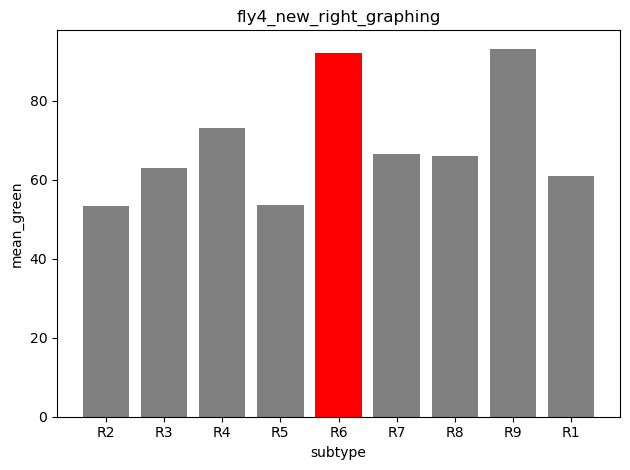

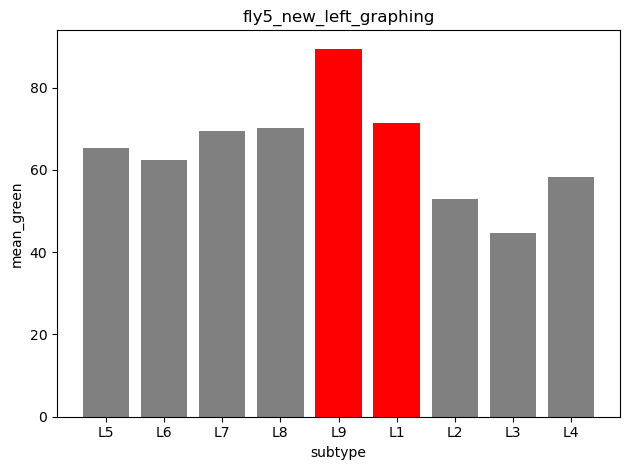

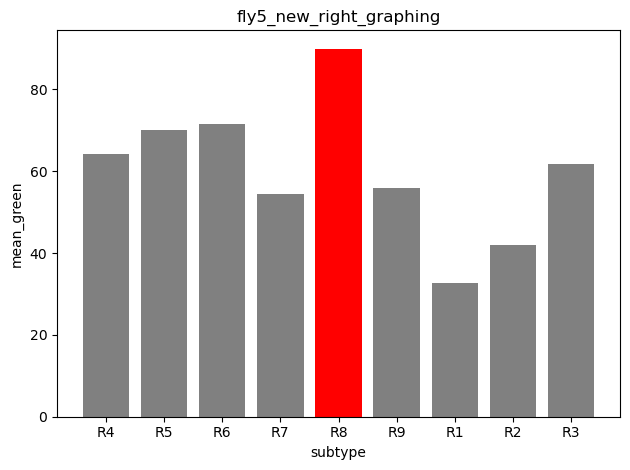

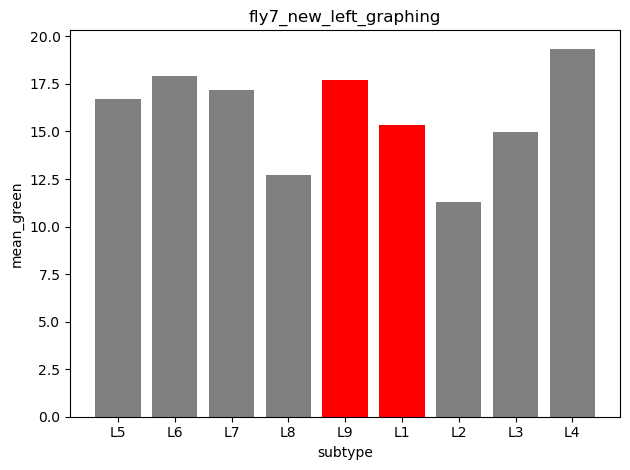

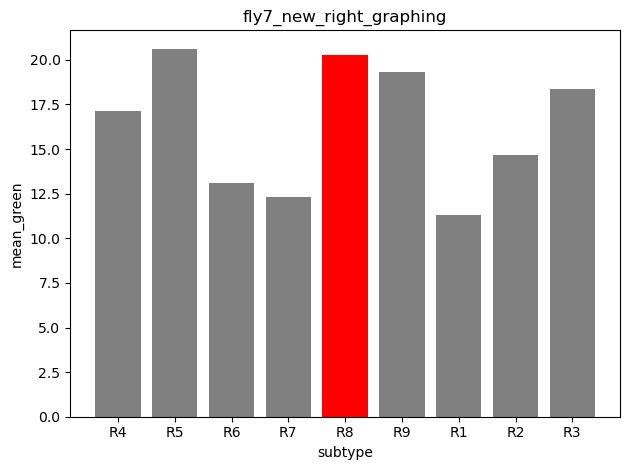

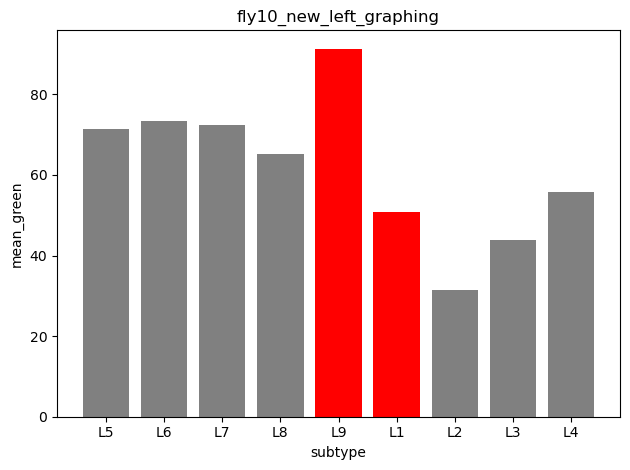

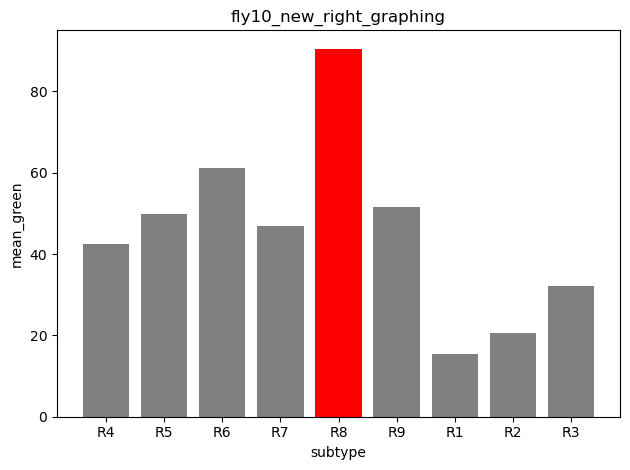

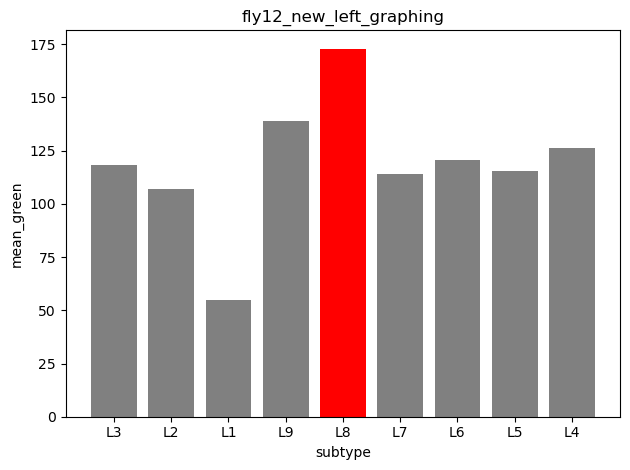

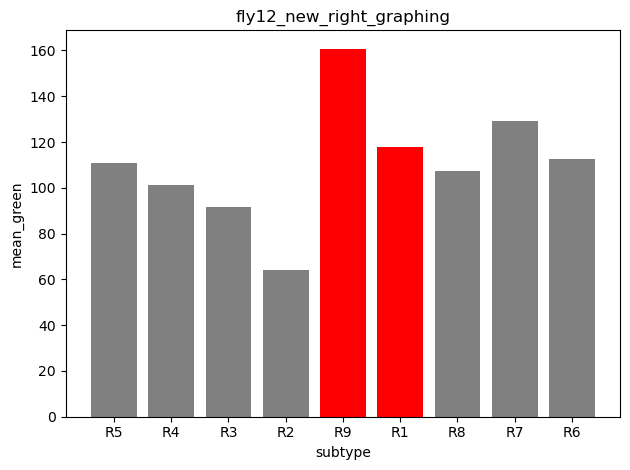

In [60]:
graphing_dfs = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
]

# 2. Loop and plot, coloring all zero‐value subtypes in red
for df_name in graphing_dfs:
    df = globals()[df_name]
    if 'mean_green' not in df.columns:
        continue

    x = df['subtype']
    y = df['mean_green']

    # 3. Find the matching shuffle_order_for_graph table
    shuffle_name = re.sub(r'_graphing$', '_shuffle_order_for_graph', df_name)
    zeros = set()
    if shuffle_name in globals():
        shuffle_df = globals()[shuffle_name]
        # 4. Collect all subtypes where value == 0
        zeros = set(shuffle_df.loc[shuffle_df['value'] == 0, 'subtype'])

    # 5. Build colors: red for any subtype in zeros, gray otherwise
    colors = ['red' if s in zeros else 'gray' for s in x]

    # 6. Plot
    plt.figure()
    plt.bar(x, y, color=colors)
    plt.xlabel('subtype')
    plt.ylabel('mean_green')
    plt.title(df_name)
    plt.tight_layout()
    plt.show()

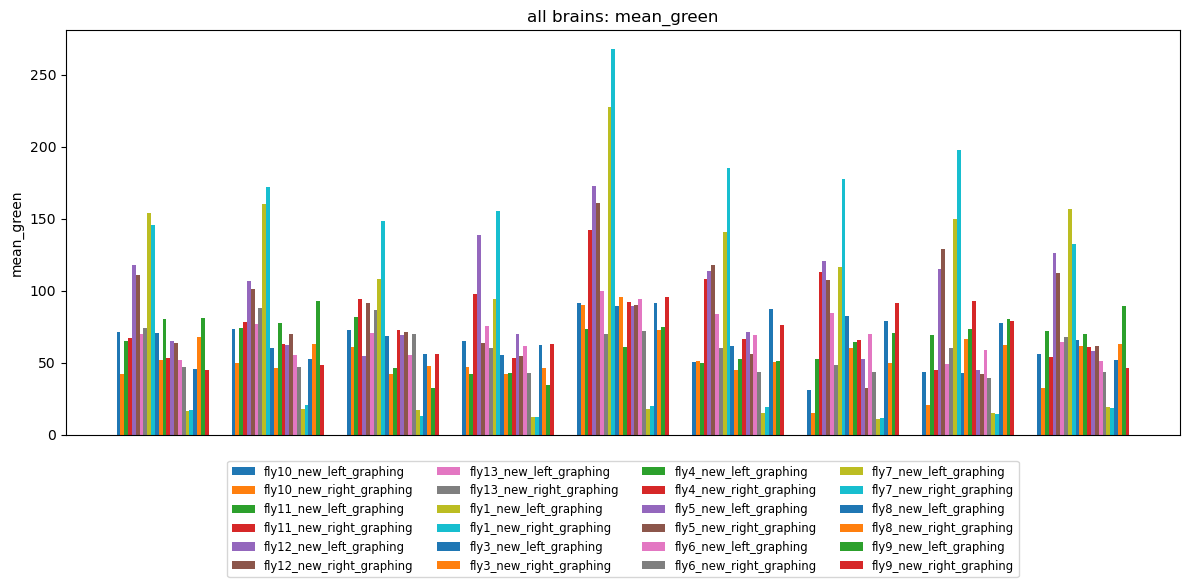

In [61]:
# 1. Gather all your graphing DataFrame names
df_names = sorted([
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
])

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(12, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['mean_green'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('all brains: mean_green')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()


In [39]:
def add_normalized_columns(df):
    # Calculate the sum of the "mean_green" column
    mean_green_sum = df['mean_green'].sum()
    
    # Add the "green_percentage" column
    df['green_percentage'] = df['mean_green'] / mean_green_sum
    
    # Calculate the mean and standard deviation for the "mean_green" column
    mean_green_mean = df['mean_green'].mean()
    mean_green_std = df['mean_green'].std()
    
    # Calculate Z-scores
    df['green_zscore_mean_at_0'] = (df['mean_green'] - mean_green_mean) / mean_green_std
    
    # Normalize the Z-scores to the range [0, 1]
    zscore_min = df['green_zscore_mean_at_0'].min()
    zscore_max = df['green_zscore_mean_at_0'].max()
    df['green_zscore_from_0_to_1'] = (df['green_zscore_mean_at_0'] - zscore_min) / (zscore_max - zscore_min)
    
    return df

# List of dataframe names (assuming you have these in globals())
dataframe_names = [name for name in globals() if isinstance(globals()[name], pd.DataFrame) and ('fly' in name) and ('left_graphing' in name or 'right_graphing' in name)]

# Apply the function to each dataframe in the list
for name in dataframe_names:
    globals()[name] = add_normalized_columns(globals()[name])

In [40]:
fly10_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1
0,L4,210.935578,55.885015,67878858.0,17983742.0,0.100551,-0.323905,0.408666
1,L3,195.179569,43.913131,32608065.0,7336435.0,0.079011,-0.984623,0.208894
2,L2,184.250290,31.394542,11895383.0,2026863.0,0.056487,-1.675513,0.000000
3,L9,387.684545,91.322420,262404284.0,61811580.0,0.164312,1.631856,1.000000
4,L1,280.008564,50.715226,150593086.0,27275460.0,0.091250,-0.609221,0.322399
5,L8,254.438758,65.295165,91817279.0,23562544.0,0.117483,0.195434,0.565690
6,L7,249.051187,72.499372,115755505.0,33696693.0,0.130445,0.593028,0.685905
7,L6,247.972702,73.403915,201196619.0,59557441.0,0.132072,0.642949,0.700999
8,L5,242.955265,71.357250,173959857.0,51092933.0,0.128390,0.529995,0.666847


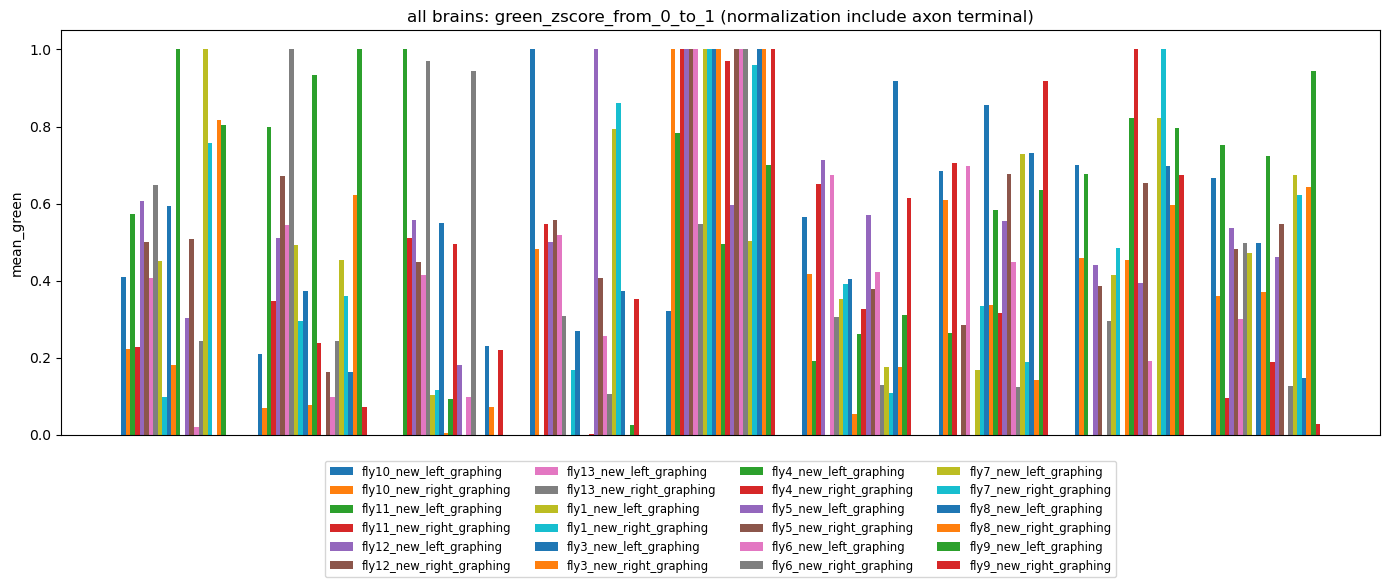

In [41]:

# 1. Gather all your graphing DataFrame names
df_names = sorted([
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
])

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_zscore_from_0_to_1'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('all brains: green_zscore_from_0_to_1 (normalization include axon terminal)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

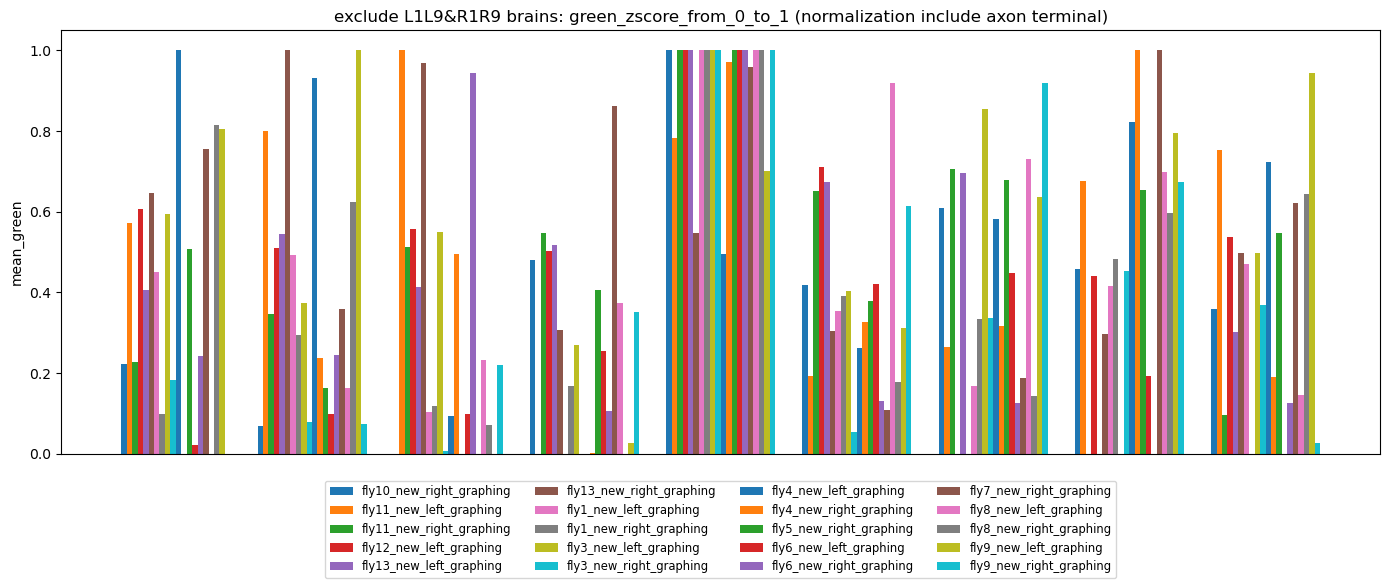

In [43]:
df_names = sorted([
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)  # match the pattern
    and name not in ['fly5_new_left_graphing', 'fly7_new_left_graphing', 'fly10_new_left_graphing', 'fly12_new_right_graphing']  # exclude specific names
])

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_zscore_from_0_to_1'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('exclude L1L9&R1R9 brains: green_zscore_from_0_to_1 (normalization include axon terminal)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

In [44]:
fly10_new_left_shuffle_order_for_graph

,subtype,value
0,L4,-3
1,L3,-2
2,L2,-1
3,L9,0
4,L1,0
5,L8,1
6,L7,2
7,L6,3
8,L5,4


In [45]:
fly10_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1
0,L4,210.935578,55.885015,67878858.0,17983742.0,0.100551,-0.323905,0.408666
1,L3,195.179569,43.913131,32608065.0,7336435.0,0.079011,-0.984623,0.208894
2,L2,184.250290,31.394542,11895383.0,2026863.0,0.056487,-1.675513,0.000000
3,L9,387.684545,91.322420,262404284.0,61811580.0,0.164312,1.631856,1.000000
4,L1,280.008564,50.715226,150593086.0,27275460.0,0.091250,-0.609221,0.322399
5,L8,254.438758,65.295165,91817279.0,23562544.0,0.117483,0.195434,0.565690
6,L7,249.051187,72.499372,115755505.0,33696693.0,0.130445,0.593028,0.685905
7,L6,247.972702,73.403915,201196619.0,59557441.0,0.132072,0.642949,0.700999
8,L5,242.955265,71.357250,173959857.0,51092933.0,0.128390,0.529995,0.666847


In [46]:
def add_normalized_columns_with_exclusion(df):
    # Extract the fly number from the dataframe name to find its corresponding shuffle dataframe
    fly_number = df.columns[0].split('_')[0]
    
    # Get the shuffle dataframe (based on the fly_number)
    shuffle_name = f"{fly_number}_new_left_shuffle_order_for_graph" if 'left' in df.columns[0] else f"{fly_number}_new_right_shuffle_order_for_graph"
    
    # Get the corresponding shuffle dataframe
    shuffle_df = globals().get(shuffle_name)
    
    if shuffle_df is not None:
        # Find rows with value 0 in the shuffle dataframe
        excluded_rows = shuffle_df[shuffle_df['value'] == 0]
        
        # Get the index of these rows based on 'subtype'
        excluded_subtypes = excluded_rows['subtype']
        
        # If there are rows to exclude, proceed
        if not excluded_subtypes.empty:
            # Create a new dataframe excluding the identified rows based on 'subtype'
            df_excluded = df[~df['subtype'].isin(excluded_subtypes)]
            
            # Calculate the sum of the "mean_green" column (excluding certain rows)
            mean_green_sum_exclude = df_excluded['mean_green'].sum()
            df['green_percentage_exclude'] = df['mean_green'] / mean_green_sum_exclude

            # Calculate the mean and standard deviation for the "mean_green" column (excluding certain rows)
            mean_green_mean_exclude = df_excluded['mean_green'].mean()
            mean_green_std_exclude = df_excluded['mean_green'].std()

            # Calculate Z-scores excluding the identified rows
            df['green_zscore_mean_at_0_exclude'] = (df['mean_green'] - mean_green_mean_exclude) / mean_green_std_exclude

            # Normalize the Z-scores to the range [0, 1] (excluding the identified rows)
            zscore_min_exclude = df['green_zscore_mean_at_0_exclude'].min()
            zscore_max_exclude = df['green_zscore_mean_at_0_exclude'].max()
            df['green_zscore_from_0_to_1_exclude'] = (df['green_zscore_mean_at_0_exclude'] - zscore_min_exclude) / (zscore_max_exclude - zscore_min_exclude)
            
            # Set the rows to NaN where they were excluded
            for subtype in excluded_subtypes:
                df.loc[df['subtype'] == subtype, ['green_zscore_mean_at_0_exclude', 'green_zscore_from_0_to_1_exclude']] = np.nan
        else:
            # If no rows are excluded, simply calculate as usual (same as original)
            mean_green_mean = df['mean_green'].mean()
            mean_green_std = df['mean_green'].std()
            df['green_zscore_mean_at_0_exclude'] = (df['mean_green'] - mean_green_mean) / mean_green_std
            zscore_min_exclude = df['green_zscore_mean_at_0_exclude'].min()
            zscore_max_exclude = df['green_zscore_mean_at_0_exclude'].max()
            df['green_zscore_from_0_to_1_exclude'] = (df['green_zscore_mean_at_0_exclude'] - zscore_min_exclude) / (zscore_max_exclude - zscore_min_exclude)
    else:
        # If no corresponding shuffle dataframe is found, set the columns to NaN
        df['green_zscore_mean_at_0_exclude'] = np.nan
        df['green_zscore_from_0_to_1_exclude'] = np.nan

    return df

# List of dataframe names (assuming you have these in globals())
dataframe_names = [name for name in globals() if isinstance(globals()[name], pd.DataFrame) and ('fly' in name) and ('left_graphing' in name or 'right_graphing' in name)]

# Apply the function to each dataframe in the list
for name in dataframe_names:
    globals()[name] = add_normalized_columns_with_exclusion(globals()[name])

In [47]:
fly10_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,L4,210.935578,55.885015,67878858.0,17983742.0,0.100551,-0.323905,0.408666,NaN,NaN
1,L3,195.179569,43.913131,32608065.0,7336435.0,0.079011,-0.984623,0.208894,NaN,NaN
2,L2,184.250290,31.394542,11895383.0,2026863.0,0.056487,-1.675513,0.000000,NaN,NaN
3,L9,387.684545,91.322420,262404284.0,61811580.0,0.164312,1.631856,1.000000,NaN,NaN
4,L1,280.008564,50.715226,150593086.0,27275460.0,0.091250,-0.609221,0.322399,NaN,NaN
5,L8,254.438758,65.295165,91817279.0,23562544.0,0.117483,0.195434,0.565690,NaN,NaN
6,L7,249.051187,72.499372,115755505.0,33696693.0,0.130445,0.593028,0.685905,NaN,NaN
7,L6,247.972702,73.403915,201196619.0,59557441.0,0.132072,0.642949,0.700999,NaN,NaN
8,L5,242.955265,71.357250,173959857.0,51092933.0,0.128390,0.529995,0.666847,NaN,NaN


In [48]:
graphing_dfs = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
]

for df_name in graphing_dfs:
    df = globals()[df_name]
    # find matching shuffle_order_for_graph table
    shuffle_name = re.sub(r'_graphing$', '_shuffle_order_for_graph', df_name)
    if shuffle_name not in globals():
        continue
    
    shuffle_df = globals()[shuffle_name]
    # which subtypes to exclude? (could be one or two)
    exclude_subtypes = shuffle_df.loc[shuffle_df['value'] == 0, 'subtype'].tolist()
    
    # build a mask of rows to exclude
    exclude_mask = df['subtype'].isin(exclude_subtypes)
    
    # compute mean and std on the INCLUDED rows only
    included = df.loc[~exclude_mask, 'mean_green']
    mean_inc = included.mean()
    std_inc  = included.std()

    # 2 new columns: raw z‑score and scaled 0–1, excluding the masked rows
    # raw zscore (NaN for excluded rows)
    z = (df['mean_green'] - mean_inc) / std_inc
    z[exclude_mask] = np.nan
    df['green_zscore_mean_at_0_exclude'] = z

    # scaled 0–1 (NaN for excluded rows)
    zmin = z[~exclude_mask].min()
    zmax = z[~exclude_mask].max()
    z01 = (z - zmin) / (zmax - zmin)
    z01[exclude_mask] = np.nan
    df['green_zscore_from_0_to_1_exclude'] = z01

In [49]:
fly8_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,L2,384.120311,45.379933,57593847.0,6804131.0,0.075052,-1.282433,0.000000,-1.222351,0.000000
1,L3,391.159933,52.838855,59664798.0,8059669.0,0.087388,-0.843699,0.161978,-0.736654,0.176204
2,L4,404.033613,56.023385,32827327.0,4551844.0,0.092655,-0.656384,0.231133,-0.529290,0.251433
3,L5,479.461818,62.530717,62101333.0,8099166.0,0.103418,-0.273623,0.372446,-0.105557,0.405157
4,L6,1059.579390,91.429031,750478890.0,64757354.0,0.151212,1.426178,1.000000,NaN,NaN
5,L7,734.868892,87.711087,160389545.0,19143471.0,0.145063,1.207488,0.919261,1.534093,1.000000
6,L8,740.380503,79.073965,138937584.0,14838783.0,0.130778,0.699452,0.731698,0.971677,0.795963
7,L9,759.271089,77.540421,64805306.0,6618230.0,0.128242,0.609249,0.698396,0.871818,0.759736
8,L1,432.793890,52.115803,53574690.0,6451311.0,0.086193,-0.886229,0.146276,-0.783737,0.159123


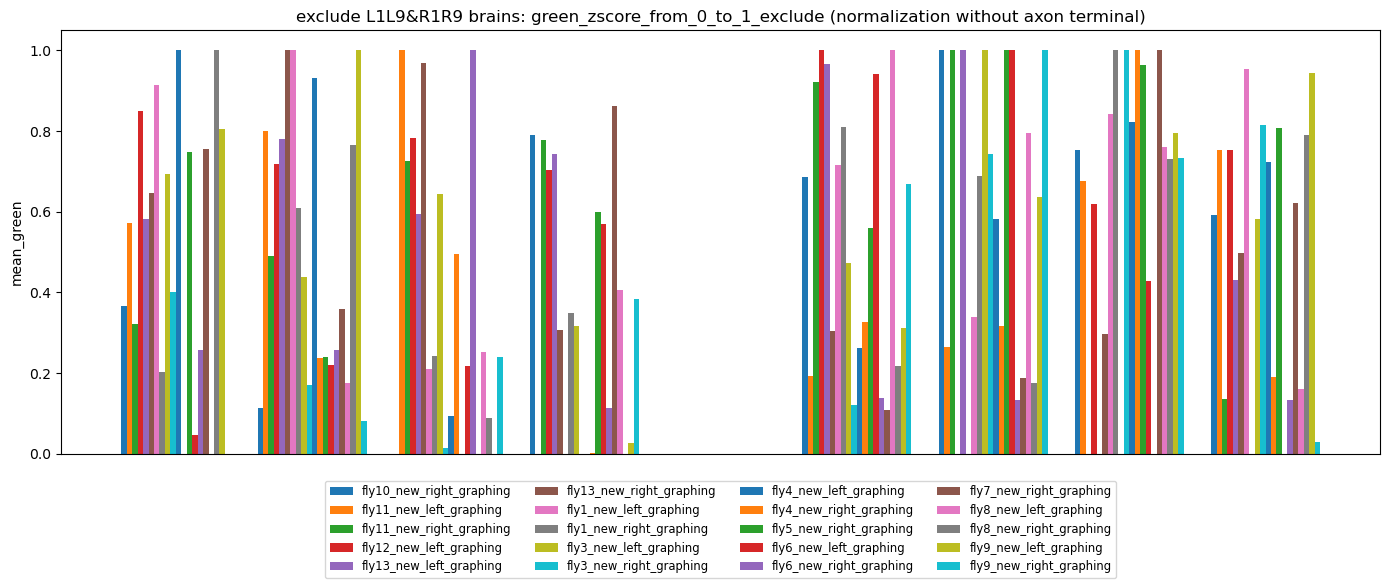

In [50]:
df_names = sorted([
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)  # match the pattern
    and name not in ['fly5_new_left_graphing', 'fly7_new_left_graphing', 'fly10_new_left_graphing', 'fly12_new_right_graphing']  # exclude specific names
])

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_zscore_from_0_to_1_exclude'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('exclude L1L9&R1R9 brains: green_zscore_from_0_to_1_exclude (normalization without axon terminal)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

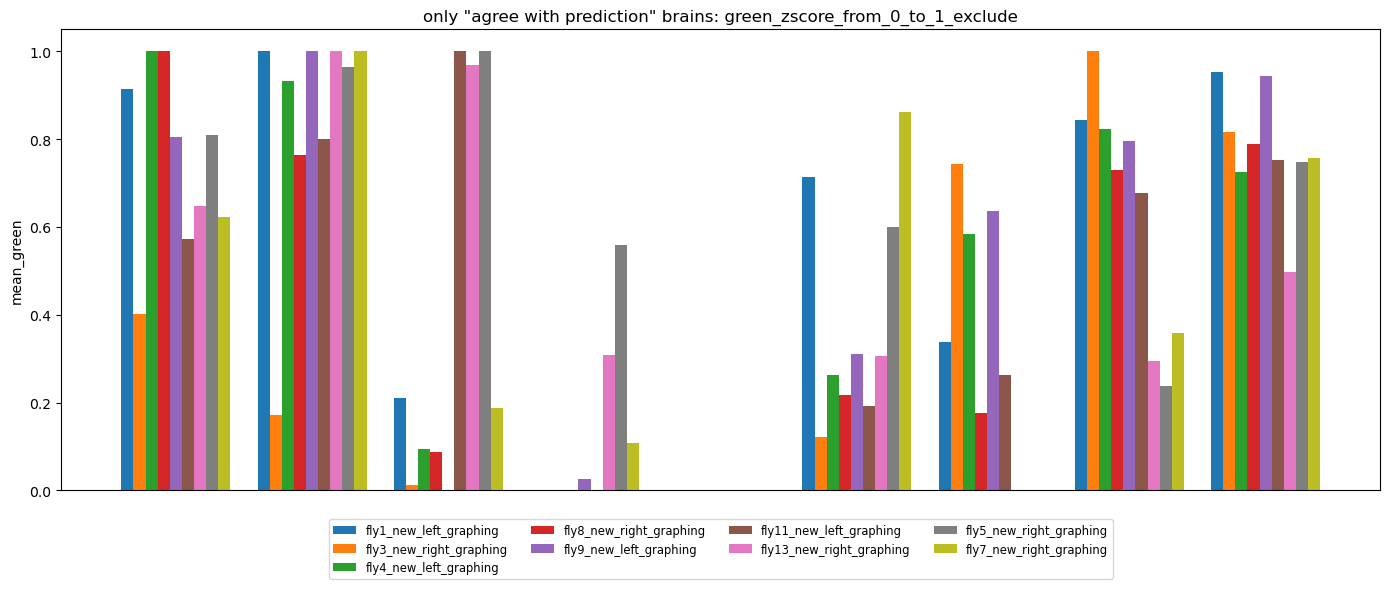

In [62]:
# only include the "agree with prediction" ones:

df_names = ['fly1_new_left_graphing', 'fly3_new_right_graphing', 'fly4_new_left_graphing', 'fly8_new_right_graphing', 'fly9_new_left_graphing', 'fly11_new_left_graphing', 
            'fly13_new_right_graphing', 'fly5_new_right_graphing', 'fly7_new_right_graphing']

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_zscore_from_0_to_1_exclude'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('only "agree with prediction" brains: green_zscore_from_0_to_1_exclude')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

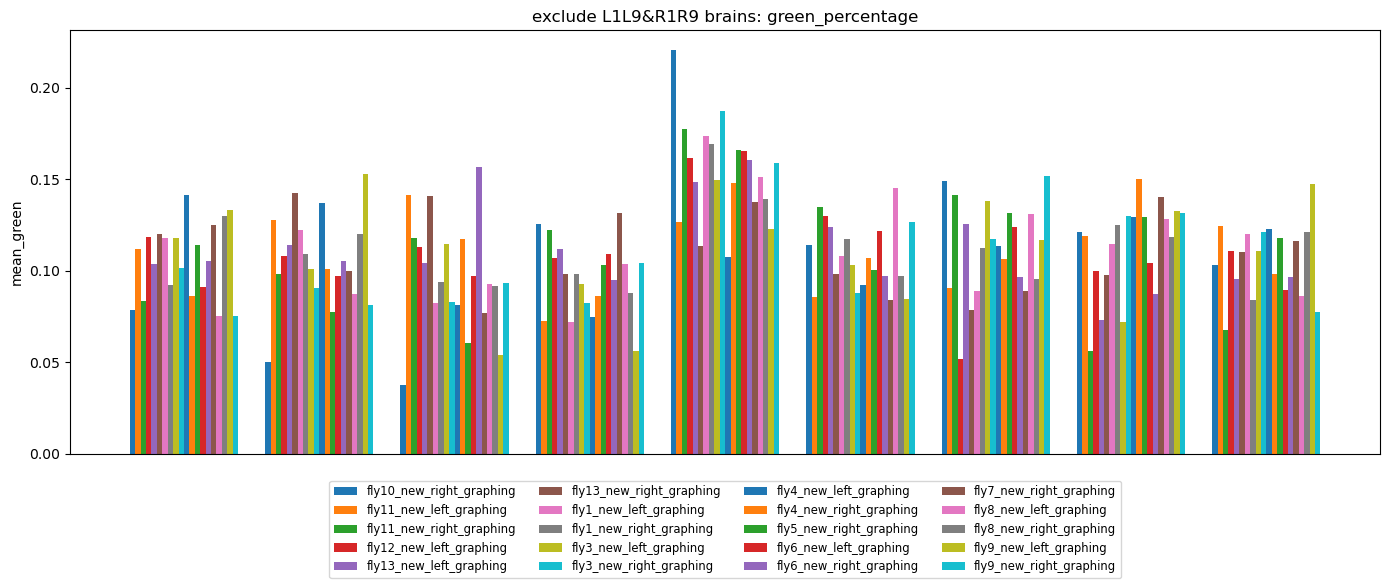

In [51]:
df_names = sorted([
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)  # match the pattern
    and name not in ['fly5_new_left_graphing', 'fly7_new_left_graphing', 'fly10_new_left_graphing', 'fly12_new_right_graphing']  # exclude specific names
])

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_percentage'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('exclude L1L9&R1R9 brains: green_percentage')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

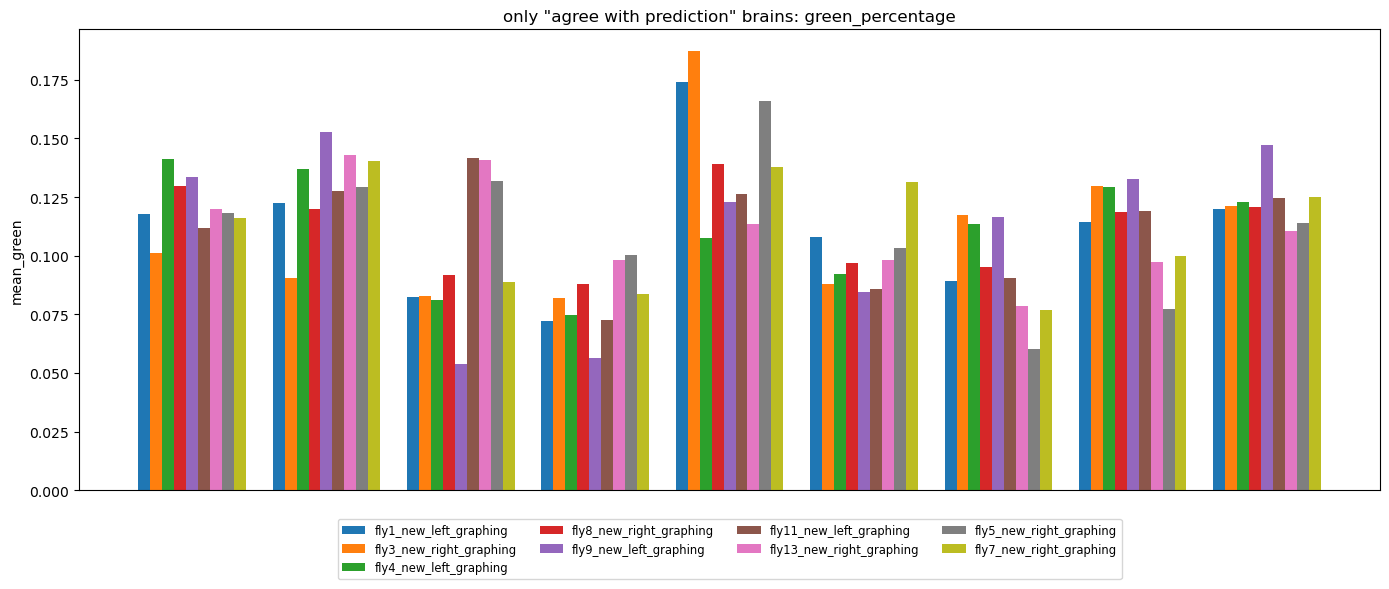

In [63]:
# only include the "agree with prediction" ones:

df_names = ['fly1_new_left_graphing', 'fly3_new_right_graphing', 'fly4_new_left_graphing', 'fly8_new_right_graphing', 'fly9_new_left_graphing', 'fly11_new_left_graphing', 
            'fly13_new_right_graphing', 'fly5_new_right_graphing', 'fly7_new_right_graphing']

# 2. Compute grouping parameters
n_groups      = len(globals()[df_names[0]])  # should be 9 rows
n_bars        = len(df_names)               # should be 16 series
total_width   = 0.8
bar_width     = total_width / n_bars
group_positions = np.arange(n_groups)

# 3. Plot each series with its own label
plt.figure(figsize=(14, 6))
for i, name in enumerate(df_names):
    y = globals()[name]['green_percentage'].values
    x = group_positions + i * bar_width
    plt.bar(x, y, width=bar_width, label=name)

# 4. Tidy up
plt.xticks([])  # hide row‑index ticks
plt.ylabel('mean_green')
plt.title('only "agree with prediction" brains: green_percentage')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize='small')  # adjust ncol to fit
plt.tight_layout()
plt.show()

In [ ]:
# going to add the L1L9 brains

In [66]:
fly10_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,L5,242.955265,71.357250,173959857.0,51092933.0,0.128390,0.529995,0.666847,0.754591,0.951281
1,L6,247.972702,73.403915,201196619.0,59557441.0,0.132072,0.642949,0.700999,0.880661,1.000000
2,L7,249.051187,72.499372,115755505.0,33696693.0,0.130445,0.593028,0.685905,0.824943,0.978468
3,L8,254.438758,65.295165,91817279.0,23562544.0,0.117483,0.195434,0.565690,0.381181,0.806978
4,L9,387.684545,91.322420,262404284.0,61811580.0,0.164312,1.631856,1.000000,NaN,NaN
5,L1,280.008564,50.715226,150593086.0,27275460.0,0.091250,-0.609221,0.322399,NaN,NaN
6,L2,184.250290,31.394542,11895383.0,2026863.0,0.056487,-1.675513,0.000000,-1.707015,0.000000
7,L3,195.179569,43.913131,32608065.0,7336435.0,0.079011,-0.984623,0.208894,-0.935900,0.297995
8,L4,210.935578,55.885015,67878858.0,17983742.0,0.100551,-0.323905,0.408666,-0.198461,0.582976


In [67]:
fly12_new_right_graphing

,subtype,mean_red,mean_green,total_red,total_green,green_percentage,green_zscore_mean_at_0,green_zscore_from_0_to_1,green_zscore_mean_at_0_exclude,green_zscore_from_0_to_1_exclude
0,R5,481.038454,110.753498,135144328.0,34564444.0,0.111272,0.006086,0.482978,0.410980,0.719070
1,R4,434.969428,101.280847,76622933.0,19851110.0,0.101755,-0.353853,0.385029,-0.053403,0.573241
2,R3,447.691150,91.524103,51865312.0,11985362.0,0.091953,-0.724586,0.284143,-0.531714,0.423039
3,R2,480.752364,64.044507,45411068.0,7008748.0,0.064344,-1.768746,0.000000,-1.878862,0.000000
4,R9,1033.024517,160.754970,392310014.0,66733892.0,0.161508,1.906024,1.000000,NaN,NaN
5,R1,741.198776,117.993778,282763354.0,47886041.0,0.118546,0.281199,0.557843,NaN,NaN
6,R8,677.891683,107.432029,136278073.0,25243913.0,0.107935,-0.120122,0.448633,0.248150,0.667937
7,R7,622.382640,129.002034,164453667.0,38606150.0,0.129606,0.699487,0.671670,1.305589,1.000000
8,R6,570.260050,112.554283,204753947.0,45454046.0,0.113081,0.074511,0.501598,0.499261,0.746792


In [78]:
def merge_rows_4_5_and_insert(df, new_subtype):
    # pick rows 4 & 5
    idx = df.index[[4,5]]
    
    # build the merged row
    new = {'subtype': new_subtype}
    new['mean_red']   = df.loc[idx, 'mean_red'].mean()
    new['mean_green'] = df.loc[idx, 'mean_green'].mean()
    for col in df.columns.difference(['subtype','mean_red','mean_green']):
        new[col] = df.loc[idx, col].sum(min_count=2)
    
    # drop originals and reset index
    df_dropped = df.drop(idx).reset_index(drop=True)
    
    # split at insertion point
    top    = df_dropped.iloc[:4]
    bottom = df_dropped.iloc[4:]
    
    # reassemble with new row at position 4
    merged_df = pd.concat([top,
                           pd.DataFrame([new]),
                           bottom],
                          ignore_index=True)
    return merged_df



In [79]:
merge_rows_4_5_and_insert(fake_df, "L1L9")

,subtype,mean_red,mean_green,col1,col2
0,A,10.0,5.0,1.0,NaN
1,B,20.0,15.0,2.0,2.0
2,C,30.0,25.0,3.0,3.0
3,D,40.0,35.0,4.0,4.0
4,L1L9,55.0,50.0,NaN,11.0
5,E,70.0,80.0,7.0,7.0


In [76]:
fake_df = pd.DataFrame({
    'subtype':    ['A', 'B', 'C', 'D', 'E', 'F', 'E'],
    'mean_red':   [10, 20, 30, 40, 50, 60, 70],
    'mean_green': [ 5, 15, 25, 35, 45, 55, 80],
    'col1':       [ 1.0,  2.0,  3.0,  4.0,   np.nan,  6.0, 7.0],
    'col2':       [  np.nan, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
})
fake_df

,subtype,mean_red,mean_green,col1,col2
0,A,10,5,1.0,NaN
1,B,20,15,2.0,2.0
2,C,30,25,3.0,3.0
3,D,40,35,4.0,4.0
4,E,50,45,NaN,5.0
5,F,60,55,6.0,6.0
6,E,70,80,7.0,7.0


In [38]:
# order of df being made:
'''
fly1: the original df made from zipursky-get main signal value.ipynb (in "subtype" column, it's glom_1).

fly_subtype: the subtype of each fly, with the subtype separated into L3 and R6, for example.

fly1_new: the df with L9...R9 in the "subtype" column.
fly1_new_right: split fly1_new into L9-L1 and R1-R9.

fly1_new_left_shuffle_order: in the end, "subtype" column is from L9-L1 OR(!!!) R1-R9, "calue" column is -4 to 4.
    for 2 axon terminals: use code
    for 3 axon termianls: manually
fly1_new_left_shuffle_order_for_graph: same as 'fly3_new_left_shuffle_order', but ordered by "value" column (so it's easier to graph).

fly1_new_right_graphing: ordered by graphing requirement.
'''

'\nfly1: the original df made from zipursky-get main signal value.ipynb (in "subtype" column, it\'s glom_1).\n\nfly_subtype: the subtype of each fly, with the subtype separated into L3 and R6, for example.\n\nfly1_new: the df with L9...R9 in the "subtype" column.\nfly1_new_right & fly1_new_left: split fly1_new into L9-L1 and R1-R9.\n\nfly1_new_left_shuffle_order: in the end, "subtype" column is from L9-L1 OR(!!!) R1-R9, "calue" column is -4 to 4.\nfly1_new_left_shuffle_order_for_graph: same as \'fly3_new_left_shuffle_order\', but ordered by "value" column (so it\'s easier to graph).\n'